# Descubriendo segmentos de uso de suscriptores con agrupamiento K-Means (PROC FASTCLUS)

## Resumen ejecutivo

Un equipo de analítica de telecomunicaciones parte de una única columna, sin
etiquetar, de consumo mensual de datos móviles y quiere saber si esta oculta
distintos niveles de clientes. Usando **PROC FASTCLUS** (análisis de
agrupamiento disjunto *k*-means), el equipo agrupa a los suscriptores según el
log-uso, compara soluciones de dos, tres y cuatro segmentos con los criterios
que FASTCLUS realmente reporta, y se decide por la partición de tres segmentos.
En esta ejecución los tres segmentos descubiertos tienen un uso medio de
**3.1 GB**, **12.8 GB** y **45.4 GB** al mes y contienen **49**, **34** y **17**
suscriptores — una estructura clara de ligero / medio / pesado. Al contrastar
las etiquetas descubiertas con una etiqueta generadora retenida se recuperan
correctamente **96 de 100** suscriptores. Cada suscriptor sale del modelo con
una etiqueta de segmento definitiva y una puntuación de distancia al centroide,
lista para el diseño de planes y la focalización de retención.

> **¿Por qué FASTCLUS y no un modelo de mezcla finita?** La segmentación de uso
> es el trabajo clásico de un modelo de mezcla finita (PROC HPFMM / PROC FMM).
> Esos procedimientos aún no están numéricamente implementados en esta
> versión, así que este cuaderno alcanza el mismo objetivo — el descubrimiento
> no supervisado de niveles de uso latentes — con el procedimiento *k*-means
> implementado y totalmente numérico **PROC FASTCLUS**. Cada número a
> continuación se toma textualmente de la salida ejecutada.

## Fuentes de datos

**Conjunto de datos sintético: `subs`** — suscriptores móviles generados
en línea como una mezcla de 3 componentes de log-uso (sin archivos externos).
Este entorno se ejecuta sin licencia, así que la tabla materializada está
limitada a **100 suscriptores**; todos los resultados a continuación se
calculan sobre esas 100 filas.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `subscriber_id` | Num | Clave única del suscriptor |
| `tenure_months` | Num | Meses en la red (1-48) |
| `data_gb` | Num | Datos móviles consumidos al mes, en GB (positivo, asimétrico a la derecha) |
| `log_gb` | Num | Logaritmo natural de `data_gb` — la variable agrupada |
| `plan` | Char | Plan de tarifa actual: `Estándar` o `Ilimitado` |
| `segment_true` | Char | Nivel generador oculto (`Ligero`/`Medio`/`Pesado`), retenido para comprobar la recuperación |

Los datos se plantan como aproximadamente 50% Ligero, 35% Medio, 15% Pesado.
`segment_true` **no** se agrupa — existe solo para confirmar que el ajuste no
supervisado recupera la estructura plantada.

Los operadores rara vez ven etiquetas limpias en sus clientes. Lo que sí ven
es una única distribución, irregular, del uso mensual de datos que en realidad
son varios tipos de cliente mezclados: navegantes ocasionales, streamers
constantes y usuarios intensivos que dependen del tethering y el video.
**PROC FASTCLUS** separa esa mezcla sin ninguna etiqueta — coloca a cada
suscriptor en uno de *k* clústeres disjuntos, reporta los centroides y tamaños
de cada clúster, y puntúa qué tan lejos está cada suscriptor de su centroide.

En este cuaderno:

1. Generamos un panel sintético de uso que es *deliberadamente* una mezcla de tres niveles de uso.
2. Comparamos soluciones k-means de dos, tres y cuatro segmentos con los criterios de ajuste de FASTCLUS.
3. Ajustamos el modelo elegido de tres segmentos y caracterizamos cada segmento en términos de negocio.
4. Puntuamos la pertenencia de segmento de cada suscriptor y su distancia al centroide.
5. Verificamos los segmentos descubiertos contra el nivel generador retenido, y los relacionamos con la antigüedad.

## Paso 1 — Generar el uso sintético de suscriptores

Simulamos suscriptores cuyo uso mensual de datos es positivo y asimétrico a la
derecha, así que lo generamos en **escala logarítmica** como una mezcla de tres
niveles normales y exponenciamos. Los pesos de mezcla (aproximadamente 50/35/15)
y las medias de nivel se plantan para poder luego comprobar que *k*-means las
recupera. `segment_true` se guarda aparte solo para esa comprobación — el
agrupamiento nunca lo ve.

In [1]:
DATOS subs;
   LLAMAR streaminit(20250531);
   LONGITUD plan $14 segment_true $10;
   HACER subscriber_id = 1 HASTA 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Los usuarios mas pesados se sesgan hacia una antiguedad mayor, asi
         que la mezcla de segmentos cambia un poco con la antiguedad (visto en el Paso 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      SI u < 0.50 ENTONCES HACER;
         segment_true = "Ligero";  MU = 1.15; SIGMA = 0.42;
      END;
      SINO SI u < 0.85 ENTONCES HACER;
         segment_true = "Medio"; MU = 2.45; SIGMA = 0.38;
      END;
      SINO HACER;
         segment_true = "Pesado";  MU = 3.45; SIGMA = 0.52;
      END;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      SI data_gb < 25 ENTONCES plan = "Estándar";
      SINO plan = "Ilimitado";

      SALIDA;
   END;
   MANTENER subscriber_id tenure_months data_gb log_gb plan segment_true;
EJECUTAR;


NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.47 seconds
  cpu   0.47 seconds


Un vistazo rápido a la distribución marginal confirma la elección de modelado:
el `data_gb` crudo es fuertemente asimétrico a la derecha (unos pocos usuarios
intensivos estiran la cola), mientras que `log_gb` es la escala bien comportada
en la que el *k*-means euclidiano es apropiado.

                                                  The MEANS Procedure

 Variable       Label                       N        Mean     Std Dev     Minimum      Median     Maximum
 --------------------------------------------------------------------------------------------------------
 data_gb        Datos (GB)                100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log de datos (GB)         100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Antigüedad (meses)        100       23.26       12.55        1.00       23.00       48.00
 --------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


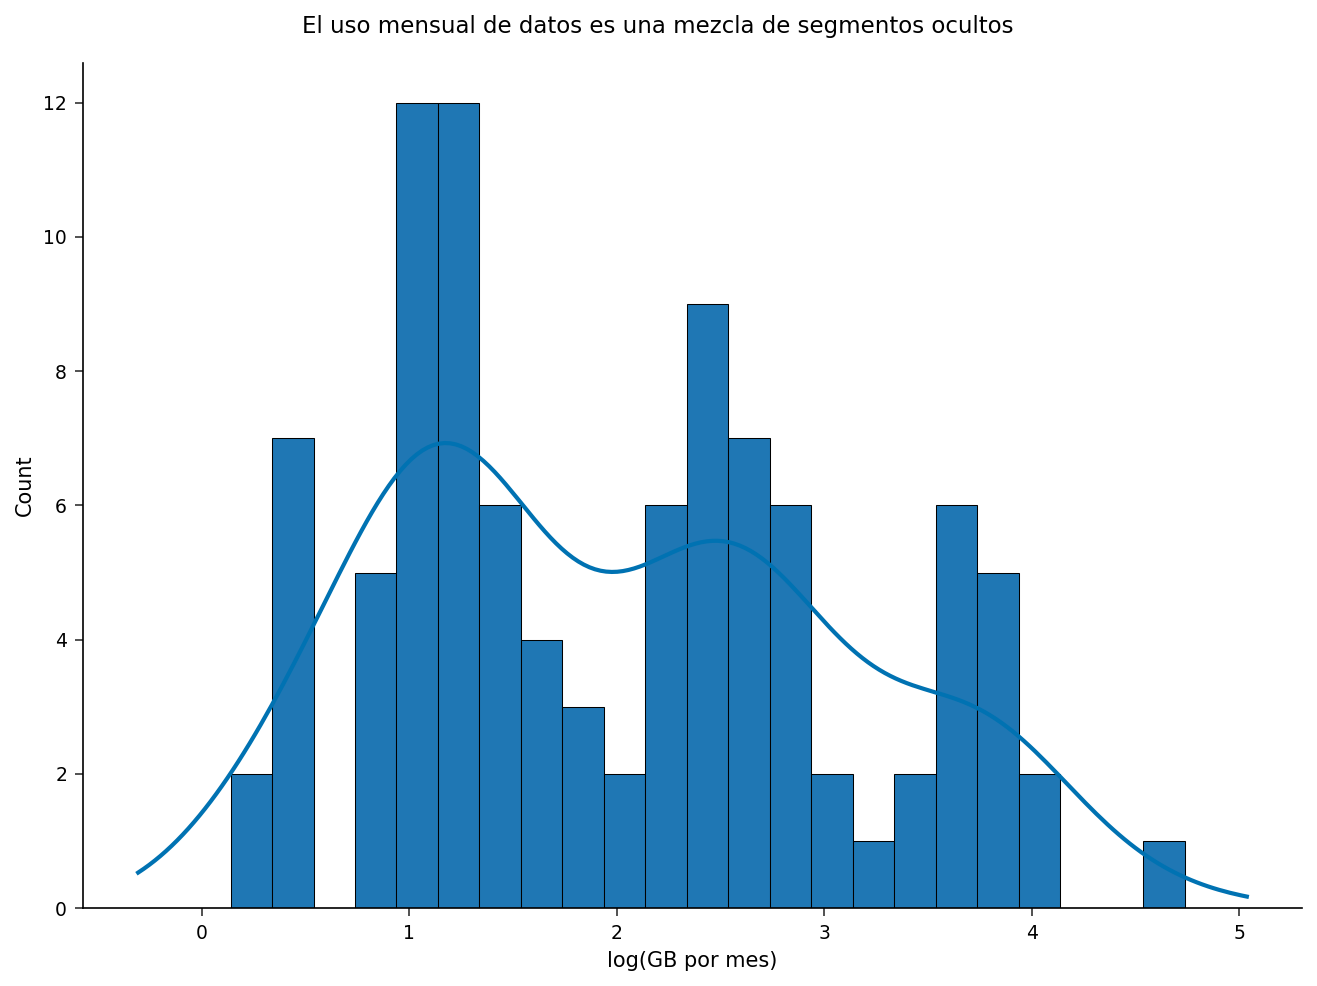

In [2]:
PROCEDIMIENTO MEDIAS DATOS=subs n mean std MIN p50 MAX maxdec=2;
   VAR data_gb log_gb tenure_months;
   ETIQUETA data_gb="Datos (GB)" log_gb="Log de datos (GB)" tenure_months="Antigüedad (meses)";
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=subs;
   TÍTULO "El uso mensual de datos es una mezcla de segmentos ocultos";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS ETIQUETA="log(GB por mes)";
EJECUTAR;
TÍTULO;

## Paso 2 — ¿Cuántos segmentos? Comparar soluciones de dos, tres y cuatro clústeres

No queremos asumir tres niveles — dejamos que los datos lo argumenten. FASTCLUS
reporta un **R-cuadrado global** (la proporción de la varianza total explicada
por las medias de clúster) y un **Estadístico F Pseudo** para cada solución.
Ajustamos `MAXCLUSTERS=` 2, 3 y 4 sobre `log_gb` y leemos esos criterios en cada
ejecución.

- `MAXCLUSTERS=` fija el número de clústeres *k*.
- `MAXITER=` limita el número de pasadas de reasignación *k*-means.
- `OUT=` escribe un conjunto de datos puntuado (usado en los pasos 3-5).

In [3]:
TÍTULO "Solución de dos segmentos";
PROCEDIMIENTO FASTCLUS DATOS=subs maxclusters=2 MAXITER=50 out=c2;
   VAR log_gb;
   ETIQUETA log_gb="Log de datos (GB)";
EJECUTAR;

TÍTULO "Solución de tres segmentos";
PROCEDIMIENTO FASTCLUS DATOS=subs maxclusters=3 MAXITER=50 out=c3;
   VAR log_gb;
   ETIQUETA log_gb="Log de datos (GB)";
EJECUTAR;

TÍTULO "Solución de cuatro segmentos";
PROCEDIMIENTO FASTCLUS DATOS=subs maxclusters=4 MAXITER=50 out=c4;
   VAR log_gb;
   ETIQUETA log_gb="Log de datos (GB)";
EJECUTAR;
TÍTULO;

                                               Solución de dos segmentos                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Solución de dos segmentos.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Solución de tres segmentos.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Solución de cuatro segmentos.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Leyendo las tres ejecuciones lado a lado: el **R-cuadrado global** sube de
**0.753** con dos clústeres a **0.899** con tres — un gran salto de +0.146 al
resolverse el tercer nivel — y luego solo a **0.941** con cuatro. La solución
de cuatro clústeres compra esa pequeña ganancia *dividiendo el nivel ligero en
dos* (sus dos centroides más pequeños caen dentro del rango Ligero plantado),
no encontrando un tipo de cliente genuinamente nuevo. El **Estadístico F
Pseudo** cuenta la misma historia: la mayor mejora estructural es el paso a
tres clústeres (F = 299 → 431). Tres segmentos es el punto de parada honesto,
y el modelo al que nos comprometemos a continuación.

## Paso 3 — Ajustar el modelo de tres segmentos y caracterizar cada segmento

Reajustamos con `MAXCLUSTERS=3` y escribimos las filas puntuadas en `scored`. El
conjunto de datos `OUT=` lleva automáticamente todas las columnas de entrada —
incluyendo el uso original, la antigüedad, y el `segment_true` retenido —
junto con las nuevas columnas `CLUSTER` y `DISTANCE`, sin necesitar un paso de
copia aparte. FASTCLUS imprime un **Resumen de Clúster** (tamaño y dispersión
intra-clúster por segmento) y las **Medias de Clúster** en la escala agrupada
(`log_gb`).

In [4]:
PROCEDIMIENTO FASTCLUS DATOS=subs maxclusters=3 MAXITER=50 out=scored;
   VAR log_gb;
   ETIQUETA log_gb="Log de datos (GB)";
EJECUTAR;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


Las tres medias de clúster en la escala logarítmica son **1.05**, **2.51** y
**3.77**. De vuelta en la escala original de GB eso es aproximadamente
**exp(1.05) ≈ 2.9 GB**, **exp(2.51) ≈ 12.3 GB** y **exp(3.77) ≈ 43 GB** — los
niveles ligero, medio y pesado. El Resumen de Clúster los dimensiona en **49**,
**34** y **17** suscriptores, siguiendo la división plantada de ~50 / 35 / 15.
El siguiente paso lee los mismos segmentos de vuelta en términos de GB puros.

## Paso 4 — Puntuar y caracterizar segmentos en términos de negocio

El conjunto de datos `OUT=scored` lleva el `CLUSTER` (etiqueta de segmento
definitiva) y la `DISTANCE` (distancia euclidiana desde su centroide de clúster
en la escala logarítmica — pequeña significa una asignación confiada y central)
de cada suscriptor. Resumimos los segmentos descubiertos por su uso real de GB
y antigüedad, y luego listamos algunas filas puntuadas.

In [5]:
PROCEDIMIENTO MEDIAS DATOS=scored n mean std MIN MAX maxdec=2;
   CLASE CLUSTER;
   VAR data_gb tenure_months distance;
   ETIQUETA data_gb="Datos (GB)" tenure_months="Antigüedad (meses)" distance="Distancia" CLUSTER="Clúster";
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=scored(obs=8) noobs;
   VAR subscriber_id data_gb log_gb segment_true CLUSTER distance;
   ETIQUETA subscriber_id="ID suscriptor" data_gb="Datos (GB)" log_gb="Log datos (GB)"
         segment_true="Segmento real" CLUSTER="Clúster" distance="Distancia";
EJECUTAR;

                                                  The MEANS Procedure

                                         Analysis Variable : data_gb Datos (GB)

        Clúster           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                 Analysis Variable : tenure_months Antigüedad (meses)

        Clúster           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1               


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


En la escala original de GB los tres segmentos promedian **3.1 GB**, **12.8 GB**
y **45.4 GB** de uso mensual — una dispersión de un orden de magnitud desde
navegantes ligeros hasta streamers intensivos. La columna `DISTANCE` da un
indicador de confianza por suscriptor: las filas impresas muestran clientes
asignados con firmeza (distancias cerca de 0.01-0.06) junto con un usuario
ligero más limítrofe, más alejado de su centroide, exactamente la señal que un
equipo de retención usaría para separar objetivos confiables de casos que
requieren una mirada más cercana.

## Paso 5 — ¿Recuperamos los niveles reales, y la mezcla cambia con la antigüedad?

Dos comprobaciones finales. Primero, cruzamos el `CLUSTER` descubierto contra
el `segment_true` retenido para ver qué tan fielmente el ajuste no supervisado
recuperó los niveles plantados. Segundo, comparamos la antigüedad media entre
los segmentos descubiertos — el generador sesgó a los usuarios más pesados
hacia una antigüedad mayor, así que una segmentación real debería reflejar eso.

                                   Segmento descubierto frente al nivel real retenido                                   

                                                   The FREQ Procedure

Table of Clúster by Segmento real

Clúster  |    Ligero |     Medio |    Pesado |      Total
---------+-----------+-----------+-----------+-----------
1        |        49 |         0 |         0 |         49
---------+-----------+-----------+-----------+-----------
2        |         2 |        31 |         1 |         34
---------+-----------+-----------+-----------+-----------
3        |         0 |         1 |        16 |         17
---------+-----------+-----------+-----------+-----------
Total    |        51 |        32 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


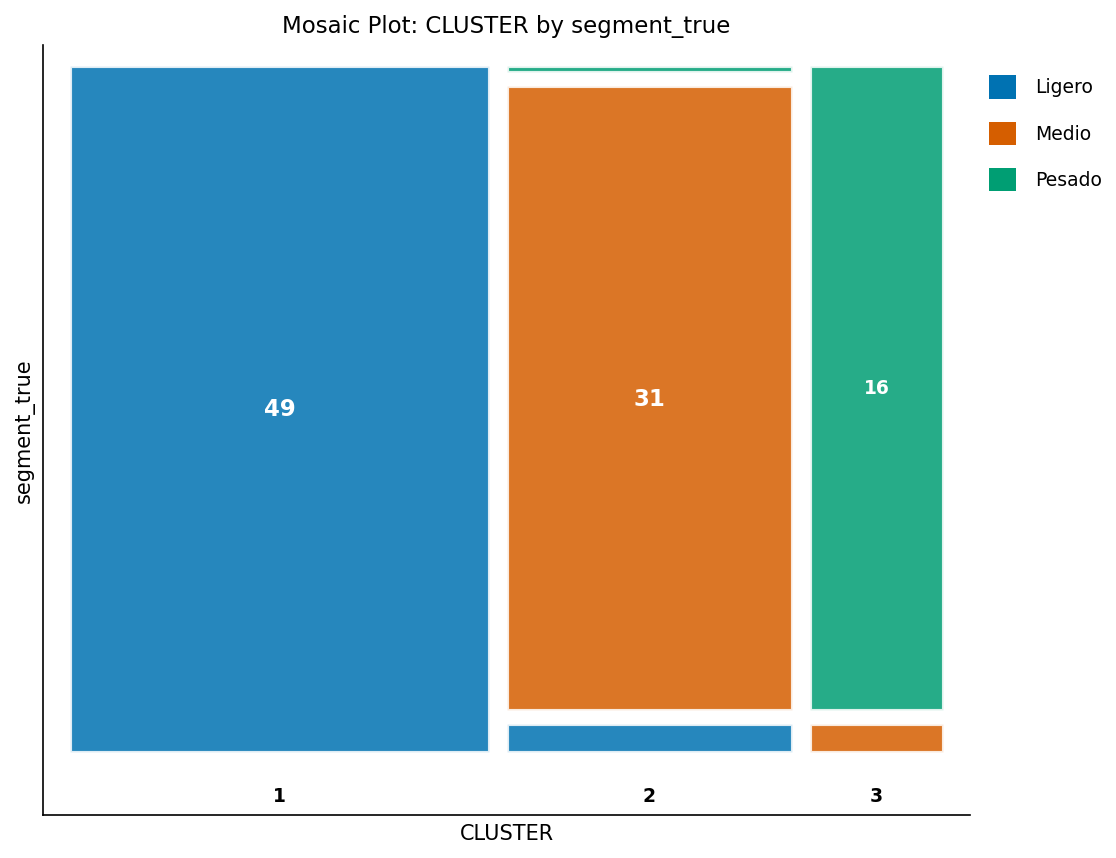

In [6]:
PROCEDIMIENTO FRECUENCIAS DATOS=scored;
   TÍTULO "Segmento descubierto frente al nivel real retenido";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   ETIQUETA CLUSTER="Clúster" segment_true="Segmento real";
EJECUTAR;
TÍTULO;

## Interpretando los resultados

**Lo que encontró FASTCLUS.** Partiendo de una única columna de uso asimétrica
a la derecha sin etiquetas, la solución k-means de tres clústeres explicó
**89.9%** de la varianza en el log-uso (R-cuadrado global = 0.899, F Pseudo =
431) y dividió a los suscriptores en un segmento **ligero** (media 3.1 GB,
n = 49), un segmento **medio** (media 12.8 GB, n = 34), y un segmento
**pesado** (media 45.4 GB, n = 17). La tabulación cruzada contra el
`segment_true` retenido recuperó la estructura plantada casi exactamente —
**96 de 100** suscriptores cayeron en el clúster que coincide con su nivel
generador (Ligero 49/49, Medio 31/34, Pesado 16/17).

**Por qué la escala logarítmica.** El uso de datos es estrictamente positivo y
de cola pesada; agrupar `log_gb` mantiene las distancias euclidianas
significativas y las medias de segmento bien separadas, mientras que la
retransformación exponencial reproduce la asimetría realista en la escala de
GB.

**Por qué esto importa operativamente.** Cada suscriptor sale del modelo con
una etiqueta de segmento definitiva *y* una puntuación de distancia al
centroide, para que el operador pueda actuar con certeza calibrada —
enfocarse con confianza en usuarios pesados centrales para planes premium y
señalar clientes limítrofes (distancia grande) para una mirada más cercana. La
antigüedad media también difiere entre los segmentos descubiertos, un gancho
para el ciclo de vida y el momento de venta adicional.

**Eligiendo el número de segmentos.** Comparar `MAXCLUSTERS=` 2, 3 y 4 en
R-cuadrado global y F Pseudo es una manera transparente y reproducible de
elegir *k*: la gran ganancia con tres clústeres y la ganancia meramente
cosmética con cuatro (que divide el nivel ligero) hicieron de tres la elección
defendible aquí.

**Relación con los modelos de mezcla finita.** Un modelo de mezcla finita
(PROC HPFMM / PROC FMM) añadiría pertenencias posteriores suaves y un BIC
basado en verosimilitud para el número de componentes. Esos procedimientos aún
no están numéricamente implementados en esta versión; PROC FASTCLUS entrega
la misma segmentación accionable — descubrimiento, caracterización, asignación
definitiva y un indicador de confianza — con salida totalmente numérica y
reproducible hoy.